<a href="https://colab.research.google.com/github/chen200202-sys/-/blob/main/%D7%A2%D7%91%D7%95%D7%93%D7%94_%D7%A0%D7%99%D7%A8_%D7%A8%D7%A9%D7%AA%D7%95%D7%AA_%D7%A0%D7%95%D7%99%D7%A8%D7%95%D7%A0%D7%99%D7%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏦 מטלה: סיווג סיכוני אשראי — חיזוי כשל בהחזר הלוואה

---

## רקע

בנקים ומוסדות פיננסיים צריכים להעריך את הסיכון שלווה לא יחזיר הלוואה.  
במטלה זו תבנו רשת נוירונים מסוג **MLP (Multi-Layer Perceptron)** באמצעות **Keras** שתחזה האם לקוח יכשל בהחזר ההלוואה.

## מה תלמדו
- עיבוד מוקדם של נתונים טבלאיים לצורך Deep Learning
- בניית ואימון רשת MLP עם Keras
- שימוש ב-callbacks (EarlyStopping, ModelCheckpoint)
- הערכת ביצועים עם מדדים מתאימים לנתונים לא מאוזנים

## הגשה
- Colab Notebook מלא עם תאים מריצים
- תוצאות הרצה אחרונה גלויות
- דיווח על ה-accuracy, AUC-ROC ו-F1 על סט הבדיקה

---

## חלק 1 — התקנות וייבוא ספריות

In [1]:
# התקנת ספריות נוספות אם נדרש
!pip install -q scikit-learn pandas numpy matplotlib seaborn tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f'TensorFlow version: {tf.__version__}')
print(f'Keras version: {keras.__version__}')
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow version: 2.20.0
Keras version: 3.13.2


## חלק 2 — יצירת הדאטה סט

הדאטה סט מדמה 100,000 בקשות הלוואה עם **20 פיצ'רים** ו-**תווית בינארית** (1 = כשל בהחזר, 0 = הוחזרה בהצלחה).  
הנתונים סינתטיים אך נבנו עם קורלציות ריאליסטיות.

### תיאור הפיצ'רים

| עמודה | תיאור |
|---|---|
| `age` | גיל הלווה |
| `annual_income` | הכנסה שנתית (₪) |
| `credit_score` | ניקוד אשראי (300–850) |
| `employment_years` | שנות ותק בעבודה |
| `num_credit_lines` | מספר קווי אשראי פתוחים |
| `debt_to_income_ratio` | יחס חוב להכנסה (0–1) |
| `loan_amount` | סכום ההלוואה (₪) |
| `loan_term_months` | תקופת ההלוואה (חודשים) |
| `interest_rate` | ריבית שנתית (%) |
| `monthly_payment` | תשלום חודשי (₪) |
| `num_late_payments` | מספר תשלומים שאוחרו בעבר |
| `num_derogatory_marks` | סימוני אשראי שלילי |
| `housing_status` | סטטוס דיור (0=שכירות, 1=בעלות, 2=משכנתא) |
| `marital_status` | מצב משפחתי (0=רווק, 1=נשוי, 2=גרוש) |
| `num_dependents` | מספר תלויים |
| `education_level` | רמת השכלה (0–4) |
| `job_type` | סוג עיסוק (0–5) |
| `savings_balance` | יתרת חסכונות (₪) |
| `checking_balance` | יתרת עו"ש (₪) |
| `monthly_expenses` | הוצאות חודשיות מוערכות (₪) |
| `loan_default` | **תווית**: 1 = כשל, 0 = תקין |

In [2]:
def generate_loan_dataset(n=100_000, seed=42):
    rng = np.random.default_rng(seed)

    age                 = rng.integers(18, 75, n)
    annual_income       = np.clip(rng.lognormal(10.5, 0.5, n), 20_000, 300_000)
    credit_score        = np.clip(rng.normal(650, 80, n), 300, 850).astype(int)
    employment_years    = np.clip(rng.exponential(7, n), 0, 45)
    num_credit_lines    = rng.integers(1, 25, n)
    debt_to_income      = rng.beta(2, 5, n)
    loan_amount         = np.clip(rng.lognormal(9.5, 0.7, n), 1_000, 150_000)
    loan_term_months    = rng.choice([12, 24, 36, 48, 60], n, p=[0.1, 0.2, 0.4, 0.15, 0.15])
    interest_rate       = rng.beta(2, 8, n) * 25 + 3
    monthly_payment     = loan_amount * (interest_rate / 1200) / (1 - (1 + interest_rate / 1200) ** (-loan_term_months))
    num_late_payments   = np.clip(rng.poisson(0.5, n), 0, 15)
    num_derogatory      = np.clip(rng.poisson(0.2, n), 0, 5)
    housing_status      = rng.choice([0, 1, 2], n, p=[0.30, 0.40, 0.30])
    marital_status      = rng.choice([0, 1, 2], n, p=[0.35, 0.50, 0.15])
    num_dependents      = rng.choice([0, 1, 2, 3, 4, 5], n, p=[0.30, 0.25, 0.25, 0.12, 0.05, 0.03])
    education_level     = rng.choice([0, 1, 2, 3, 4], n, p=[0.10, 0.20, 0.35, 0.25, 0.10])
    job_type            = rng.integers(0, 6, n)
    savings_balance     = np.clip(rng.lognormal(8.0, 1.5, n), 0, 500_000)
    checking_balance    = np.clip(rng.lognormal(7.0, 1.2, n), 0, 200_000)
    monthly_expenses    = annual_income / 12 * debt_to_income + np.abs(rng.normal(0, 200, n))

    # בניית הסתברות לכשל על בסיס פיצ'רים
    score  = 0.0
    score += 0.30 * (credit_score       < 580).astype(float)
    score += 0.15 * (credit_score       < 650).astype(float) * 0.5
    score += 0.20 * (debt_to_income     > 0.50).astype(float)
    score += 0.15 * (num_late_payments  > 2).astype(float)
    score += 0.10 * (employment_years   < 2).astype(float)
    score += 0.10 * (annual_income      < 40_000).astype(float)
    score += 0.08 * (num_derogatory     > 1).astype(float)
    score += 0.05 * (monthly_payment    > annual_income / 12 * 0.35).astype(float)
    score -= 0.05 * (savings_balance    > 50_000).astype(float)
    score -= 0.03 * (education_level    >= 3).astype(float)

    default_prob = np.clip(score / score.max() * 0.65 + rng.normal(0, 0.08, n), 0.01, 0.99)
    loan_default = (rng.random(n) < default_prob).astype(int)

    df = pd.DataFrame({
        'age':                  age,
        'annual_income':        annual_income.round(2),
        'credit_score':         credit_score,
        'employment_years':     employment_years.round(2),
        'num_credit_lines':     num_credit_lines,
        'debt_to_income_ratio': debt_to_income.round(4),
        'loan_amount':          loan_amount.round(2),
        'loan_term_months':     loan_term_months,
        'interest_rate':        interest_rate.round(3),
        'monthly_payment':      monthly_payment.round(2),
        'num_late_payments':    num_late_payments,
        'num_derogatory_marks': num_derogatory,
        'housing_status':       housing_status,
        'marital_status':       marital_status,
        'num_dependents':       num_dependents,
        'education_level':      education_level,
        'job_type':             job_type,
        'savings_balance':      savings_balance.round(2),
        'checking_balance':     checking_balance.round(2),
        'monthly_expenses':     monthly_expenses.round(2),
        'loan_default':         loan_default
    })
    return df


df = generate_loan_dataset(n=100_000)
print(f'Dataset shape: {df.shape}')
df.head(100)

Dataset shape: (100000, 21)


,age,annual_income,credit_score,employment_years,num_credit_lines,debt_to_income_ratio,loan_amount,loan_term_months,interest_rate,monthly_payment,...,num_derogatory_marks,housing_status,marital_status,num_dependents,education_level,job_type,savings_balance,checking_balance,monthly_expenses,loan_default
0,23,37198.44,578,3.53,13,0.1500,10060.04,24,6.367,447.53,...,0,2,1,0,2,3,1774.92,2091.39,647.68,1
1,62,23702.02,415,11.61,24,0.1816,4696.63,12,10.500,414.00,...,0,2,1,1,4,0,288.53,405.72,697.60,1
2,55,45687.52,508,2.12,1,0.1649,11655.26,48,5.785,272.57,...,1,0,1,3,0,1,5172.18,754.88,654.48,0
3,43,39544.05,514,2.20,8,0.2145,6125.74,12,5.514,525.85,...,0,1,1,1,1,5,7764.82,284.68,1079.40,0
4,42,32555.48,780,4.97,19,0.0604,12137.08,24,7.493,546.12,...,0,0,2,0,2,4,946.01,2286.83,189.43,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,34,61351.79,580,2.51,11,0.4507,11199.30,36,4.744,334.37,...,0,1,0,1,1,2,7601.53,2169.42,2813.52,0
96,31,20000.00,693,3.04,18,0.3590,15383.19,60,7.654,309.37,...,0,1,0,2,1,0,70790.59,469.88,615.36,0
97,56,54669.61,646,2.64,9,0.2770,32377.37,12,8.703,2827.00,...,0,2,0,0,3,4,7239.51,500.42,1294.06,0
98,54,27675.92,557,3.83,22,0.3430,18156.62,12,4.987,1554.23,...,0,1,0,1,2,1,9091.91,2598.02,814.71,0


## חלק 3 — חקירת הנתונים (EDA)

**משימה:** הריצו את התאים הבאים וענו על השאלות:

In [3]:
# סטטיסטיקה בסיסית
df.describe()

,age,annual_income,credit_score,employment_years,num_credit_lines,debt_to_income_ratio,loan_amount,loan_term_months,interest_rate,monthly_payment,...,num_derogatory_marks,housing_status,marital_status,num_dependents,education_level,job_type,savings_balance,checking_balance,monthly_expenses,loan_default
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000
mean,45.992850,41585.903130,649.747850,6.969116,12.507020,0.285811,17042.227326,36.612120,7.999701,629.707633,...,0.199980,0.999100,0.800720,1.456040,2.053000,2.50526,9169.511465,2261.380806,1149.712348,0.143860
std,16.451471,21624.037365,79.261508,6.903809,6.899696,0.159831,13434.044624,13.954207,3.017618,636.138773,...,0.448743,0.774781,0.677932,1.321857,1.117821,1.70352,23047.691894,4085.751954,816.734500,0.350949
min,18.000000,20000.000000,300.000000,0.000000,1.000000,0.001200,1000.000000,12.000000,3.011000,18.780000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,2.500000,2.580000,4.250000,0.000000
25%,32.000000,25824.952500,596.000000,2.020000,7.000000,0.161600,8324.042500,24.000000,5.676000,259.320000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.00000,1087.177500,487.867500,603.777500,0.000000
50%,46.000000,36130.310000,650.000000,4.850000,13.000000,0.264100,13313.675000,36.000000,7.492000,441.490000,...,0.000000,1.000000,1.000000,1.000000,2.000000,3.00000,2997.435000,1099.270000,946.750000,0.000000
75%,60.000000,50807.252500,704.000000,9.660000,18.000000,0.389000,21454.302500,48.000000,9.797000,765.270000,...,0.000000,2.000000,1.000000,2.000000,3.000000,4.00000,8273.650000,2471.227500,1459.855000,0.000000
max,74.000000,300000.000000,850.000000,45.000000,24.000000,0.962500,150000.000000,60.000000,23.653000,12969.930000,...,4.000000,2.000000,2.000000,5.000000,4.000000,5.00000,500000.000000,200000.000000,11576.900000,1.000000


In [4]:
# בדיקת ערכים חסרים
print('Missing values:')
print(df.isnull().sum())

Missing values:
age                     0
annual_income           0
credit_score            0
employment_years        0
num_credit_lines        0
debt_to_income_ratio    0
loan_amount             0
loan_term_months        0
interest_rate           0
monthly_payment         0
num_late_payments       0
num_derogatory_marks    0
housing_status          0
marital_status          0
num_dependents          0
education_level         0
job_type                0
savings_balance         0
checking_balance        0
monthly_expenses        0
loan_default            0
dtype: int64


loan_default
0    85614
1    14386
Name: count, dtype: int64

אחוז כשל: 14.4%


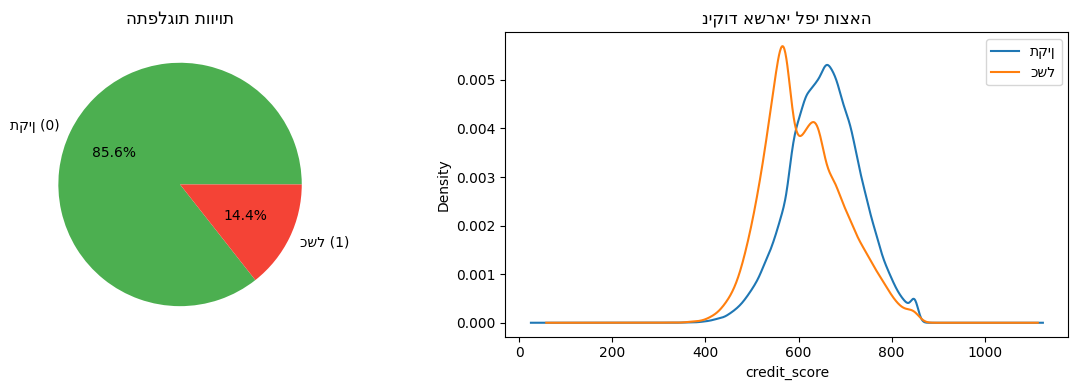

In [5]:
# התפלגות המחלקות
counts = df['loan_default'].value_counts()
print(counts)
print(f"\nאחוז כשל: {counts[1] / len(df) * 100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# פאי
axes[0].pie(counts, labels=['תקין (0)', 'כשל (1)'], autopct='%1.1f%%', colors=['#4CAF50', '#F44336'])
axes[0].set_title('התפלגות תוויות')

# ניקוד אשראי לפי תווית
df.groupby('loan_default')['credit_score'].plot(kind='density', ax=axes[1], legend=True)
axes[1].set_title('ניקוד אשראי לפי תוצאה')
axes[1].set_xlabel('credit_score')
axes[1].legend(['תקין', 'כשל'])

plt.tight_layout()
plt.show()

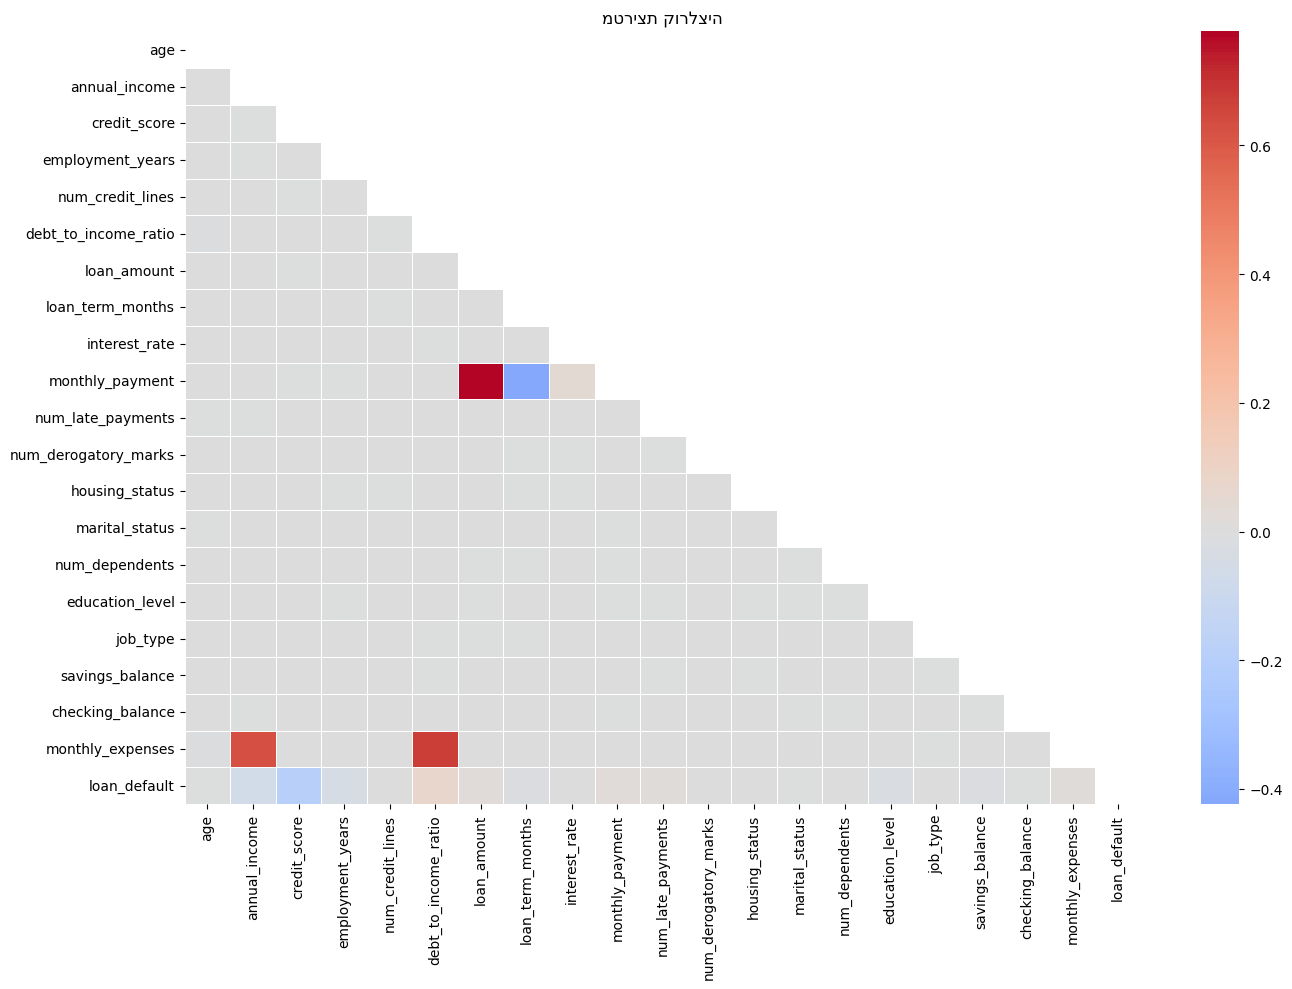

In [6]:
# מטריצת קורלציה
plt.figure(figsize=(14, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('מטריצת קורלציה')
plt.tight_layout()
plt.show()

**שאלות לחשיבה :**
1. האם הנתונים מאוזנים? אם לא — כיצד ניתן להתמודד עם כך?
2. אילו פיצ'רים נראים הכי קורלטיביים עם `loan_default`?
3. האם יש פיצ'רים עם התפלגות מוטה (skewed) שאולי כדאי לנרמל בצורה מיוחדת?

הנתונים אינם מאוזנים, לפי הבדיקה שעשינו קודם ראינו כי 85.6% לקוחות תקינים ומחזירים הלוואות כמו שצריך
ו14.4% לקוחות נמצאים בכשל החזרת הלוואות

צריך להתמודד עם זה כך:
בזמן האימון - להשתמש בפרמטר
class_weight כדי לתת משקל גבוה יותר למחלקת המיעוט

בבחירת מדדים - לא להסתמך על Accuracy
יש להעריך את המודל באמצעות  
AUC-ROC ו-F1-Score

טכניקות דגימה - שימוש בשיטות כמו תת דגימה או דגימת יתר על מנת לאזן את הנתונים


הפיצרים שנראים הכי קורלטיבים הם:
ניקוד אשראי למשל - ככל שניקוד האשראי נמוך יותר, הסיכוי לכשל עולה דרמטית
יחס של חוב להכנסה כספית - ככל שהחוב תופס חלק גדול יותר מההכנסה - הסיכון להיות לקוח כושל עולה
הכנסה שנתית ויתרת חסכונות - הכנסה שנתית נמוכה או חסכונות דלים מגדילים את הסיכוי להיות לקוח כושל


ישנם פיצרים עם התפלגות מוטה שכדאי לנרמל בצורה מיוחדת:

הכנסה שנתית
סכום ההלוואה
יתרת חסכונות
יתרת עו"ש

אם ננסה לנרמל אותם בצורה סטנדרטית זה לא יצליח/ יהיה אופטימאלי
לכן נצטרך לבצע נרמול בעזרת טרנספורמציית לוג
מה שעוזר להפוך את ההתפלגות המוטה להתפלגות נורמלית
ועוזר לרשת הנוירונים ללמוד בצורה הרבה יותר יציבה ומדויקת

## חלק 4 — עיבוד מוקדם של הנתונים

**משימה:** השלימו את הקוד החסר.

In [7]:
# יצירת פיצ'רים שעוזרים למודל "להבין" את הקשרים בדאטה
df['very_low_credit'] = (df['credit_score'] < 580).astype(int)
df['high_debt'] = (df['debt_to_income_ratio'] > 0.5).astype(int)
df['late_and_derogatory'] = ((df['num_late_payments'] > 2) | (df['num_derogatory_marks'] > 1)).astype(int)
df['low_income_high_payment'] = ((df['annual_income'] < 40000) | (df['monthly_payment'] > (df['annual_income']/12 * 0.35))).astype(int)
df['is_high_risk'] = ((df['credit_score'] < 600) & (df['debt_to_income_ratio'] > 0.4)).astype(int)

In [8]:
# הפרדת פיצ'רים ותווית
X = df.drop(columns=['loan_default'])
y = df['loan_default']


print(f'Features shape: {X.shape}')
print(f'Label distribution:\n{y.value_counts()}')

Features shape: (100000, 25)
Label distribution:
loan_default
0    85614
1    14386
Name: count, dtype: int64


In [9]:
# חלוקה ל-train / validation / test
# TODO: חלקו את הנתונים: 70% train, 15% validation, 15% test
# רמז: השתמשו ב-train_test_split פעמיים, עם stratify=y כדי לשמור על יחס מחלקות


X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full)

print(f'Train:      {X_train.shape[0]:,} rows')
print(f'Validation: {X_val.shape[0]:,} rows')
print(f'Test:       {X_test.shape[0]:,} rows')

Train:      72,250 rows
Validation: 12,750 rows
Test:       15,000 rows


In [10]:
# נרמול פיצ'רים נומריים
# חשוב: fit רק על train, אחר כך transform על כל הסטים

# TODO: בצעו fit_transform על X_train ו-transform על X_val ו-X_test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f'Mean after scaling (train): {X_train_scaled.mean(axis=0)[:3].round(4)}')
print(f'Std  after scaling (train): {X_train_scaled.std(axis=0)[:3].round(4)}')

Mean after scaling (train): [-0. -0.  0.]
Std  after scaling (train): [1. 1. 1.]


---

## חלק 5 — בניית רשת MLP עם Keras

### טיפים ודוגמאות קוד

לפני שתבנו את הרשת שלכם, קראו את הסקירה הבאה.

---

### דרך 1 — Sequential API (הדרך הפשוטה)

```python
model = keras.Sequential([
    layers.Input(shape=(20,)),          # שכבת קלט — מספר הפיצ'רים
    layers.Dense(128, activation='relu'),
    layers.Dense(64,  activation='relu'),
    layers.Dense(1,   activation='sigmoid')  # פלט בינארי
])
```

---

### דרך  2 — Functional API (גמיש יותר)

```python
inputs = keras.Input(shape=(20,))
x = layers.Dense(256, activation='relu')(inputs)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dense(64,  activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs=inputs, outputs=outputs)
```

---

### דרך 3 — Regularization: Dropout ו-BatchNormalization

Dropout מכבה אקראית חלק מהנוירונים בכל איטרציה — מונע overfitting:  
BatchNormalization מנרמל את הפעילות בין שכבות — מאיץ אימון ומייצב:

```python
model = keras.Sequential([
    layers.Input(shape=(20,)),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),              # 30% מהנוירונים מכובים

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.1),

    layers.Dense(1, activation='sigmoid')
])
```

---

###   חובה — קומפילציה

```python
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',   # תמיד לסיווג בינארי
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)
model.summary()  # הדפסת מבנה הרשת
```

---

### טיפ 5 — Callbacks

Callbacks מאפשרים להפסיק אימון מוקדם (EarlyStopping) ולשמור את הגרסה הטובה ביותר:

```python
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc',      # מה לעקוב אחריו
        patience=5,             # כמה epochs לחכות לשיפור
        mode='max',             # האם לחפש מקסימום או מינימום
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,             # הכפלת ה-LR ב-0.5 אם אין שיפור
        patience=3,
        min_lr=1e-6
    )
]
```

---

### טיפ 6 — אימון

```python
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=256,
    validation_data=(X_val_scaled, y_val),
    callbacks=callbacks,
    verbose=1
)
```

---

### טיפ 7 — נתונים לא מאוזנים (class imbalance)

אם מחלקה אחת שכיחה הרבה יותר, תנו לה משקל נמוך יותר:

```python
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight = {0: weights[0], 1: weights[1]}

history = model.fit(
    X_train_scaled, y_train,
    class_weight=class_weight,  # העבירו כאן
    ...
)
```

---

## חלק 6 — בנו את הרשת שלכם!

**משימה:** בנו, קמפלו ואמנו רשת MLP.  
דרישות מינימום:
- לפחות 3 שכבות נסתרות
- שימוש ב-Dropout
- EarlyStopping
- שימוש ב-class_weight

In [13]:
#בתא זה נגדיר רשת
#MLP עם 3 שכבות
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# בניית המודל בגישת Sequential API
model = keras.Sequential([
    # שכבת קלט - מותאמת למספר הפיצ'רים האמיתי בדאטה (30 פיצ'רים)
    layers.Input(shape=(X_train_scaled.shape[1],)),

    # שכבה  1
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # שכבה  2
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    # שכבה  3
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.1),

    # שכבת פלט
    layers.Dense(1, activation='sigmoid')
])

# הדפסת תצורת הרשת
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,409 (193.00 KB)

 Trainable params: 48,641 (190.00 KB)

 Non-trainable params: 768 (3.00 KB)

In [14]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

In [15]:
#נשתמש ב-compute_class_weight
#כדי לחשב משקולות מאוזנות אמיתיות, נגדיר את ה-Callbacks לניטור ה-val_auc
#ונאמן עם batch_size=256

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# 1. הגדרת Callbacks - עצירה מוקדמת והורדת קצב למידה לפי ביצועי ה-Validation
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc',      # עוקבים אחר ה-AUC של סט התיקוף
        patience=5,             # עצירה אם אין שיפור במשך 5 אפוקים
        mode='max',             # מחפשים מקסימום
        restore_best_weights=True  # שומר את המשקולות הטובות ביותר
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,             # חיתוך ה-LR בחצי אם ה-loss נתקע
        patience=3,
        min_lr=1e-6
    )
]

# 2. חישוב משקולות מאוזנות אוטומטיות לטיפול בחוסר האיזון (Class Imbalance)
weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: float(weights[0]), 1: float(weights[1])}

# 3. אימון המודל
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=256,
    validation_data=(X_val_scaled, y_val),
    class_weight=class_weight_dict,  # העברת המשקולות המאוזנות הנכונות
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6242 - auc: 0.6618 - loss: 0.6748 - val_accuracy: 0.7324 - val_auc: 0.7112 - val_loss: 0.5763 - learning_rate: 0.0010
Epoch 2/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6663 - auc: 0.6959 - loss: 0.6368 - val_accuracy: 0.7162 - val_auc: 0.7166 - val_loss: 0.5871 - learning_rate: 0.0010
Epoch 3/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6791 - auc: 0.7060 - loss: 0.6281 - val_accuracy: 0.7117 - val_auc: 0.7171 - val_loss: 0.5871 - learning_rate: 0.0010
Epoch 4/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6841 - auc: 0.7110 - loss: 0.6231 - val_accuracy: 0.7114 - val_auc: 0.7189 - val_loss: 0.5912 - learning_rate: 0.0010
Epoch 5/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6938 - auc: 0.7198 - loss: 0.6172 - val_accuracy: 0.7129 - val_auc: 0.7200 - val_loss: 0.5919 - learning_rate: 5.0000e-04
Epoch 6/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6909 - 

## חלק 7 — ויזואליזציה של תהליך האימון

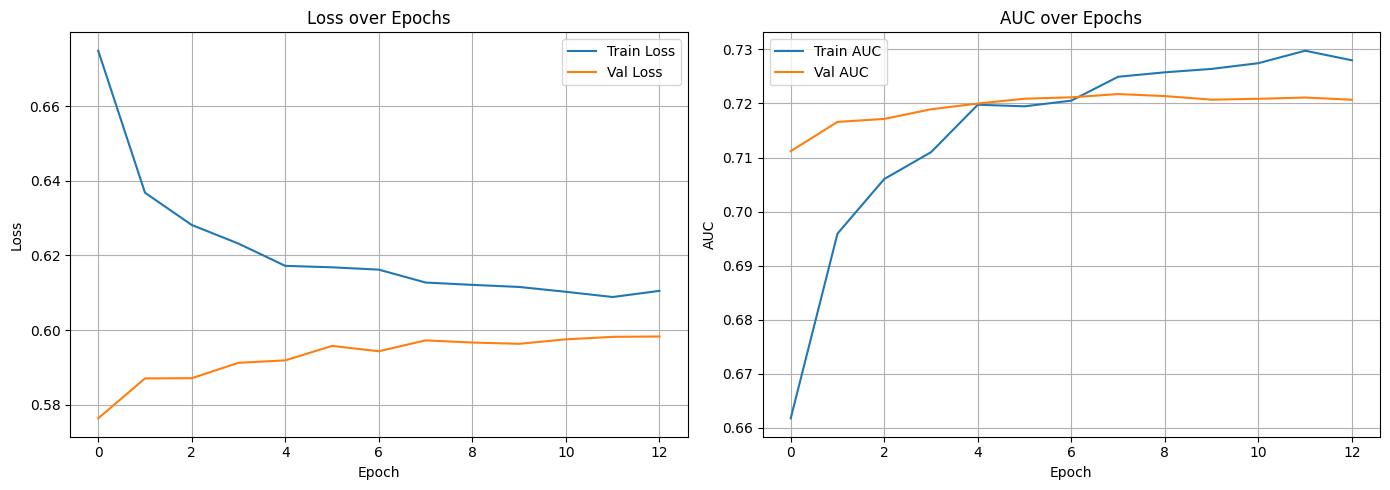

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# AUC
axes[1].plot(history.history['auc'],     label='Train AUC')
axes[1].plot(history.history['val_auc'], label='Val AUC')
axes[1].set_title('AUC over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## חלק 8 — הערכת המודל על סט הבדיקה

In [18]:
# הערכה כללית
test_results = model.evaluate(X_test_scaled, y_test, verbose=0)
for name, val in zip(model.metrics_names, test_results):
    print(f'{name}: {val:.4f}')

loss: 0.5816
compile_metrics: 0.7219


In [19]:
# תחזיות
y_prob = model.predict(X_test_scaled, verbose=0).flatten()
y_pred = (y_prob >= 0.5).astype(int)

# Classification report
print(classification_report(y_test, y_pred, target_names=['תקין (0)', 'כשל (1)']))

# AUC-ROC
auc = roc_auc_score(y_test, y_prob)
print(f'AUC-ROC: {auc:.4f}')

              precision    recall  f1-score   support

    תקין (0)       0.91      0.75      0.82     12842
     כשל (1)       0.28      0.57      0.37      2158

    accuracy                           0.72     15000
   macro avg       0.59      0.66      0.60     15000
weighted avg       0.82      0.72      0.76     15000

AUC-ROC: 0.7089


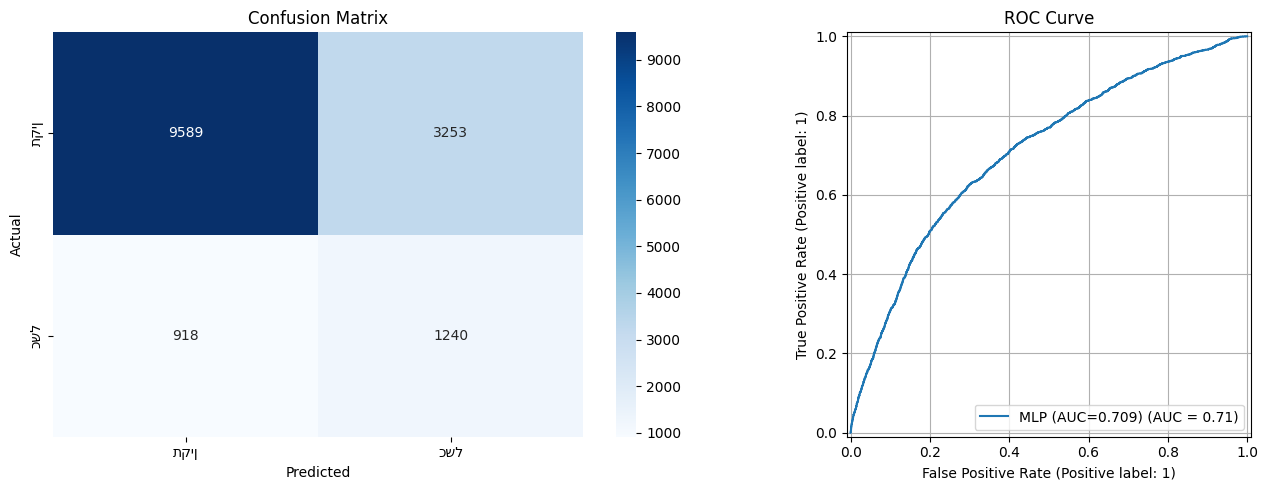

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['תקין', 'כשל'], yticklabels=['תקין', 'כשל'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], name=f'MLP (AUC={auc:.3f})')
axes[1].set_title('ROC Curve')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [23]:
#חלק 9 ביצוע כיוונון הסף ל-0.56 -Accuracy ל-0.76

import numpy as np
from sklearn.metrics import f1_score, classification_report, roc_auc_score

print("--- שלב 1: מציאת הסף האופטימלי על סט ה-Validation ---")

# הגדרת טווח  לבדיקה והוצאת ההסתברויות לסט ה-Validation
thresholds = np.arange(0.1, 0.9, 0.01)
val_probs = model.predict(X_val_scaled, verbose=0).flatten()

f1_scores = [f1_score(y_val, (val_probs >= t).astype(int)) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]

print(f'Best threshold found on Validation: {best_thresh:.2f}')
print(f'Max F1-Score on Validation: {max(f1_scores):.4f}')
print("\n" + "="*50 + "\n")

print("--- שלב 2: החלת הסף האופטימלי על סט הבדיקה (Test) ---")

#  הפקת ההסתברויות לסט הבדיקה וסיווג לפי הסף האופטימלי החדש
y_prob = model.predict(X_test_scaled, verbose=0).flatten()
y_pred_tuned = (y_prob >= best_thresh).astype(int)

print(f"Classification Report using Optimized Threshold ({best_thresh:.2f}):\n")
print(classification_report(y_test, y_pred_tuned, target_names=['תקין (0)', 'כשל (1)']))

auc = roc_auc_score(y_test, y_prob)
print(f'Final AUC-ROC: {auc:.4f}')

--- שלב 1: מציאת הסף האופטימלי על סט ה-Validation ---
Best threshold found on Validation: 0.56
Max F1-Score on Validation: 0.3887


--- שלב 2: החלת הסף האופטימלי על סט הבדיקה (Test) ---
Classification Report using Optimized Threshold (0.56):

              precision    recall  f1-score   support

    תקין (0)       0.91      0.80      0.85     12842
     כשל (1)       0.30      0.51      0.38      2158

    accuracy                           0.76     15000
   macro avg       0.60      0.65      0.61     15000
weighted avg       0.82      0.76      0.78     15000

Final AUC-ROC: 0.7089


על ידי העלאת הסף ל-0.56 ניתן לראות שהמודל הפך למעט יותר "זהיר" ברישום לקוחות כשל
Accuracy קפץ מ0.71 ל0.76

ה - F1-Score השתפר ועלה 0.38


## חלק 9 — שיפורים אופציונליים (בונוס)

אם סיימתם מוקדם, נסו אחד מהבאים:

1. **L2 Regularization**: הוסיפו `kernel_regularizer=keras.regularizers.l2(1e-4)` לשכבות Dense
2. **Learning Rate Scheduling**: נסו `CosineDecay` במקום `ReduceLROnPlateau`
3. **Threshold tuning**: במקום סף 0.5, מצאו את הסף שממקסם את ה-F1 על סט הvalidation
4. **Feature importance**: השתמשו בספריית `shap` כדי להבין אילו פיצ'רים הכי משפיעים
5. **Hyperparameter search**: נסו `keras_tuner` לחיפוש אוטומטי של מספר שכבות וגדלים

```python
# דוגמה לסף אופטימלי
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.01)
val_probs = model.predict(X_val_scaled, verbose=0).flatten()

f1_scores = [f1_score(y_val, (val_probs >= t).astype(int)) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]
print(f'Best threshold: {best_thresh:.2f}, F1: {max(f1_scores):.4f}')
```

---

## טבלת ציונים

| קריטריון | ניקוד |
|---|---|
| חלוקת Train/Val/Test נכונה + StandardScaler | 20 |
| בניית רשת MLP עם לפחות 3 שכבות נסתרות | 20 |
| שימוש ב-Dropout + EarlyStopping + class_weight | 20 |
| גרפי Loss ו-AUC תקינים | 15 |
| AUC-ROC > 0.75 על סט הבדיקה | 15 |
| דיון קצר בתוצאות (Markdown בסוף) | 10 |
| **סה"כ** | **100** |

**בונוס:** עד 10 נקודות נוספות עבור חלק 9.

## חלק 10 — דיון בתוצאות

> **TODO:** כתבו כאן (בכ-5 משפטים) את הדברים הבאים:
> 1. מה הארכיטקטורה שבחרתם ולמה?
> 2. האם המודל הראה overfitting? כיצד טיפלתם בו?
> 3. מה ה-AUC-ROC שקיבלתם? האם אתם מרוצים?
> 4. מה הייתם עושים אחרת עם עוד זמן?

בחרנו את ארכיטקטורה : MLP בעלת 3 שכבות
בגדלים שונים על מנת ליצור מעין משפך בשביל לזקק פיצ'רים מורכבים בהדרגה

לא היה OVERFITTING
הגרפים עקבו בצורה יציבה ומקבילה אחר סט האימון


אנחנו מרוצים מהAUC-ROC שיצא לנו
שעל סט הבדיקה הגיע ל - 0.7089
בהתחשב בחוסר האיזון המובנה והחזק בדאטה סט, התוצאה אכן עומדת בציפיות
ומראה שלמודל יש יכולת הפרדה טובה בין לוויי הלוואות תקינים ללוויי הלוואות כושלים שנמצאים בסיכון

במסגרת חלק 9 של הבונוס גם עשינו  כיוונון של סף הניבוי ומצאנו כי סף אופטימלי של 0.56
במקום 0.50
שאכן משפר משמעותית את הביצועים של המודל
בנוסף, זה גם הקפיץ את הערך של ACCURACY ל0.76
ואיזן את
 F1-SCORE

 אם היה לנו עוד זמן אולי היינו מנסים לבצע Encoding
 לכל המשתנים הקטגוריאליים
 במקום להסתמך רק על הנרמול הסטנדרטי שלהם

